In [65]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [66]:
# 1. Load dan mempersiapkan data 

df = pd.read_csv('DATA AI - Cut.csv')

df['Polusi_Angka'] = df['Kategori Paparan Polusi'].map({
    'Rendah': 0, 'Sedang': 1, 'Tinggi': 2
})

feature_names = ['Asam Askorbat (mg/g)', 'Total Klorofil', 'Kadar Ph', 'Kadar Air', 'Polusi_Angka']
X = df[feature_names].values
Y = df['Label Toleransi'].values
plant_names = df['Nama Latin'].values

print(f"Total data  : {len(X)} baris")
print(f"Label       : {np.unique(Y)}")

Total data  : 266 baris
Label       : ['Intermediet' 'Moderat' 'Sensitif' 'Toleran']


In [67]:
# Pengecekan missing values dan distribusi data
print(df[feature_names].isnull().sum())
print('\n')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 10)
print(df[feature_names].describe())
print('\n')
print(df['Kategori Paparan Polusi'].value_counts())

Asam Askorbat (mg/g)    0
Total Klorofil          0
Kadar Ph                0
Kadar Air               0
Polusi_Angka            0
dtype: int64


       Asam Askorbat (mg/g)  Total Klorofil    Kadar Ph   Kadar Air  Polusi_Angka
count            266.000000      266.000000  266.000000  266.000000    266.000000
mean               3.049007        5.515801    6.031992   70.721579      1.778195
std                3.742003        7.016256    0.783580   18.330267      0.555975
min                0.001000        0.040000    3.300000   10.110000      0.000000
25%                0.600000        2.292500    5.600000   60.547500      2.000000
50%                1.950000        3.190000    6.005000   74.000000      2.000000
75%                4.000000        6.060000    6.400000   84.000000      2.000000
max               30.000000       41.940000    8.400000   98.800000      2.000000


Kategori Paparan Polusi
Tinggi    225
Sedang     23
Rendah     18
Name: count, dtype: int64


In [68]:
# 2. Melakukan split data 

all_indices = df.index.values

X_train, X_test, Y_train, Y_test, names_train, names_test, idx_train, idx_test = train_test_split(
    X, Y, plant_names, all_indices, test_size=0.2, random_state=42, stratify=Y
)

print(f"Data training : {len(X_train)}")
print(f"Data testing  : {len(X_test)}")

import collections
print("Distribusi Y_train:", collections.Counter(Y_train))
print("Distribusi Y_test :", collections.Counter(Y_test))

Data training : 212
Data testing  : 54
Distribusi Y_train: Counter({'Sensitif': 71, 'Moderat': 59, 'Toleran': 49, 'Intermediet': 33})
Distribusi Y_test : Counter({'Sensitif': 18, 'Moderat': 15, 'Toleran': 12, 'Intermediet': 9})


In [69]:
# 3. Fungsi Decision Tree (ID3)

# Entropy
# Menghitung tingkat ketidakmurnian (impurity) dari sekumpulan label.
def entropy(y):
    counts = Counter(y)
    total  = len(y)
    result = 0
    for label, count in counts.items():
        p       = count / total
        result -= p * np.log2(p + 1e-9)  # Penambahan 1e-9 untuk menghindari log(0)
    return result


# Information Gain
# Mengukur penurunan entropy setelah data dibagi berdasarkan threshold tertentu.
def information_gain(X_col, y, threshold):
    parent_entropy = entropy(y)
    left_mask      = X_col <= threshold
    right_mask     = ~left_mask

    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return 0

    n = len(y)
    weighted_entropy = (left_mask.sum()  / n) * entropy(y[left_mask]) \
                     + (right_mask.sum() / n) * entropy(y[right_mask])
    return parent_entropy - weighted_entropy

# Best Split 
# Mencari kombinasi fitur dan threshold terbaik yang menghasilkan Information Gain tertinggi.
def best_split(X, y):
    best_ig        = -1
    best_feature   = None
    best_threshold = None

    for feature_idx in range(X.shape[1]):
        unique_vals = np.unique(X[:, feature_idx])
        thresholds  = (unique_vals[:-1] + unique_vals[1:]) / 2  # midpoint

        for threshold in thresholds:
            ig = information_gain(X[:, feature_idx], y, threshold)
            if ig > best_ig:
                best_ig        = ig
                best_feature   = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold, best_ig

# Build Tree (Rekursif) 
# Membangun pohon keputusan secara rekursif menggunakan algoritma ID3.
def build_tree(X, y, depth=0, max_depth=5):
    # Berhenti: semua label sudah sama
    if len(set(y)) == 1:
        return {'leaf': True, 'label': y[0]}

    # Berhenti: sudah mencapai max_depth
    if depth >= max_depth:
        most_common = Counter(y).most_common(1)[0][0]
        return {'leaf': True, 'label': most_common}

    feature_idx, threshold, ig = best_split(X, y)

    # Berhenti: entropy sama seperti sebelum displit 
    if ig == 0:
        most_common = Counter(y).most_common(1)[0][0]
        return {'leaf': True, 'label': most_common}

    left_mask  = X[:, feature_idx] <= threshold
    right_mask = ~left_mask
    return {
        'leaf'         : False,
        'feature'      : feature_idx,
        'feature_name' : feature_names[feature_idx],
        'threshold'    : threshold,
        'ig'           : ig,
        'left'         : build_tree(X[left_mask],  y[left_mask],  depth + 1, max_depth),
        'right'        : build_tree(X[right_mask], y[right_mask], depth + 1, max_depth),
    }

# Predict
def predict_one(tree, x):
    if tree['leaf']:
        return tree['label']
    if x[tree['feature']] <= tree['threshold']:
        return predict_one(tree['left'], x)
    else:
        return predict_one(tree['right'], x)

def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

In [70]:
# 4. Latihan Model dan Prediksi

tree = build_tree(X_train, Y_train, max_depth=5)

predictions = predict(tree, X_test)
score = accuracy_score(Y_test, predictions)

print(f"Decision Tree Accuracy Score: {score * 100:.2f}%")

Decision Tree Accuracy Score: 62.96%


In [71]:
# 5. Menampilkan Hasil

results_df = pd.DataFrame({
    'Nama Latin'      : names_test,
    'Real Label'      : Y_test,
    'Predicted Label' : predictions
}, index=idx_test)

print("Sample of Decision Tree Predictions vs Real Plants:")
print(results_df.head(20).to_string())

Sample of Decision Tree Predictions vs Real Plants:
                                                 Nama Latin   Real Label Predicted Label
142                                    Butea frondosa Roxb.  Intermediet        Sensitif
213  Fernando adenophyllum (Syn. Haplophragma adenophyllum)     Sensitif        Sensitif
238                                       Michelia champaca     Sensitif         Moderat
190                                   Barringtonia asiatica     Sensitif        Sensitif
16                               Citrus lemon (L.) Burm. f.      Toleran        Sensitif
31                                           Hamelia patens      Toleran         Toleran
220                                       Helianthus annuus     Sensitif         Toleran
55                                Ravenala madagascariensis      Toleran         Toleran
149                                             Ephedra sp.  Intermediet     Intermediet
173                                           Senna pallid

In [72]:
# 6. Visualisasi Tree

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

sklearn_tree = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
sklearn_tree.fit(X_train, Y_train)

# Visualisasi
plt.figure(figsize=(80, 20), dpi=300)

plot_tree(
    sklearn_tree,
    feature_names=feature_names,
    class_names=sklearn_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree: Klasifikasi Toleransi Pohon", fontsize=10)
plt.savefig('Gambar_Tree_ID3.png', dpi=300, bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

 Intermediet       0.50      0.33      0.40         9
     Moderat       0.64      0.60      0.62        15
    Sensitif       0.64      0.78      0.70        18
     Toleran       0.67      0.67      0.67        12

    accuracy                           0.63        54
   macro avg       0.61      0.59      0.60        54
weighted avg       0.62      0.63      0.62        54



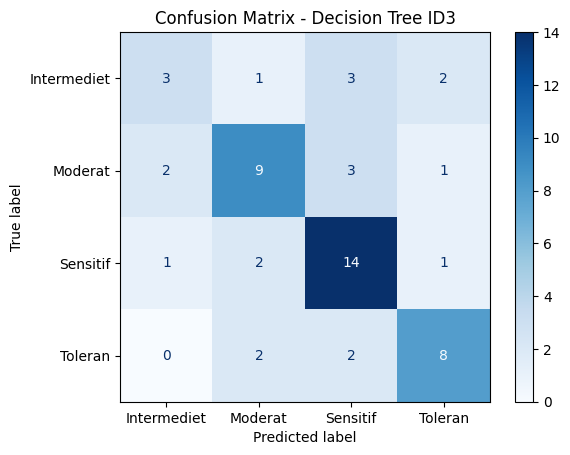

In [73]:
# 7. Mengecek performa model lewat Confusion Matrix dan Classification Report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print(classification_report(Y_test, predictions))

cm = confusion_matrix(Y_test, predictions, labels=['Intermediet', 'Moderat', 'Sensitif', 'Toleran'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Intermediet', 'Moderat', 'Sensitif', 'Toleran'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree ID3")
plt.savefig('Confusion_Matrix_ID3.png', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
# 8. K-Fold Cross Validation

def kfold_cross_validation(X, Y, k=5, max_depth=5):
    np.random.seed(42)
    idx    = np.random.permutation(len(X))
    X_shuf = X[idx]
    Y_shuf = Y[idx]
    folds  = np.array_split(np.arange(len(X)), k)
    scores = []

    for fold_num, test_idx in enumerate(folds):
        train_idx = np.concatenate([folds[i] for i in range(k) if i != fold_num])

        X_tr, X_te = X_shuf[train_idx], X_shuf[test_idx]
        Y_tr, Y_te = Y_shuf[train_idx], Y_shuf[test_idx]

        fold_tree = build_tree(X_tr, Y_tr, max_depth=max_depth)
        preds     = predict(fold_tree, X_te)
        acc       = accuracy_score(Y_te, preds)
        scores.append(acc)

        print(f"  Fold {fold_num + 1}: {acc * 100:.2f}%")

    return np.array(scores)

print("K-Fold Cross Validation (k=5):")
dt_scores = kfold_cross_validation(X, Y, k=5, max_depth=5)

print(f"\nDT Accuracy for each of the 5 rounds: {np.round(dt_scores, 4)}")
print(f"Decision Tree K-Fold Average Accuracy: {dt_scores.mean() * 100:.2f}%")

K-Fold Cross Validation (k=5):
  Fold 1: 61.11%
  Fold 2: 66.04%
  Fold 3: 56.60%
  Fold 4: 64.15%
  Fold 5: 62.26%

DT Accuracy for each of the 5 rounds: [0.6111 0.6604 0.566  0.6415 0.6226]
Decision Tree K-Fold Average Accuracy: 62.03%
